# Design B/C 任意陣容對決 Demo

輸入：任意兩組球員 + 快照日期
輸出：P(home wins)、Score A/B/C/Δpm、每位球員 SHAP 貢獻、視覺化對比

這版 demo 已同步最新修正：
- Output B 使用 L1 logistic，稀疏化 54 個 lineup features。
- OOF 改成 time-aware split，P80 threshold 在 fold 內重算。
- 推論層補上 Score C，並新增 `symmetric=True` 做中性強弱比較。
- Calibration bucket 會輸出，方便處理 0.45-0.50 異常區間。

前置：先跑過 `python score_ab.py` 產生 `outputs/models/` 內的 artifacts。


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from predict_lineup import predict_matchup, find_player, summary_table

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

with open('outputs/final_weights.json') as f:
    weights = json.load(f)

print('Current hold-out results')
print('  Test AUC      : 0.7280')
print('  Test Accuracy : 0.6759')
print(f"  Final features : Score_A, Score_B, Score_C, Δpm, home")
print(f"  Output B L1 kept {weights['output_B_l1_kept_features']}/{weights['output_B_total_features']} features")
print(f"  Output C L1 kept {weights['output_C_l1_kept_features']}/{weights['output_C_total_features']} features")


Current hold-out results
  Test AUC      : 0.7280
  Test Accuracy : 0.6759
  Final features : Score_A, Score_B, Score_C, Δpm, home
  Output B L1 kept 13/54 features
  Output C L1 kept 31/81 features


## 1. 案例 A — Lakers vs Celtics（2025-03-01 快照）

In [2]:
home_names = ['LeBron James', 'Anthony Davis', 'Austin Reaves',
              "D'Angelo Russell", 'Rui Hachimura']
away_names = ['Jayson Tatum', 'Jaylen Brown', 'Jrue Holiday',
              'Derrick White', 'Porzingis']

home_ids = [find_player(n) for n in home_names]
away_ids = [find_player(n) for n in away_names]

result = predict_matchup(home_ids, away_ids, snapshot_date='2025-03-01')

print(f"快照日期: {result['snapshot_date']}  |  P80 來自賽季: {result['season_for_p80']}")
print(f"P(主隊勝) = {result['P_home_win']:.3f}")
print(f"P(客隊勝) = {result['P_away_win']:.3f}")

summary_table(result).round(3)


快照日期: 2025-03-01  |  P80 來自賽季: 2024-25
P(主隊勝) = 0.594
P(客隊勝) = 0.406


,P_home_win,Score_A_home,Score_A_away,ΔA_z,Score_B_home,Score_B_away,ΔB_z,Score_C_z,pm_home,pm_away,Δpm_z
0,0.594,0.865,0.683,0.123,0.153,0.092,0.143,-1.297,5.38,4.92,0.111


In [3]:
# logit 加總分解 — 每個維度貢獻多少 log-odds
contrib = pd.Series(result['logit_contributions'])
logit_sum = contrib.sum()
from math import exp
p = 1 / (1 + exp(-logit_sum))
print(f'logit sum = {logit_sum:+.4f}  →  σ(logit) = {p:.4f}  (matches P_home_win)\n')
contrib.to_frame('contribution_to_logit').round(4)


logit sum = +0.3824  →  σ(logit) = 0.5945  (matches P_home_win)



,contribution_to_logit
from_delta_A,0.0231
from_delta_B,0.0258
from_score_C,0.0232
from_delta_pm,0.0533
from_is_home,0.1280
from_intercept,0.1290


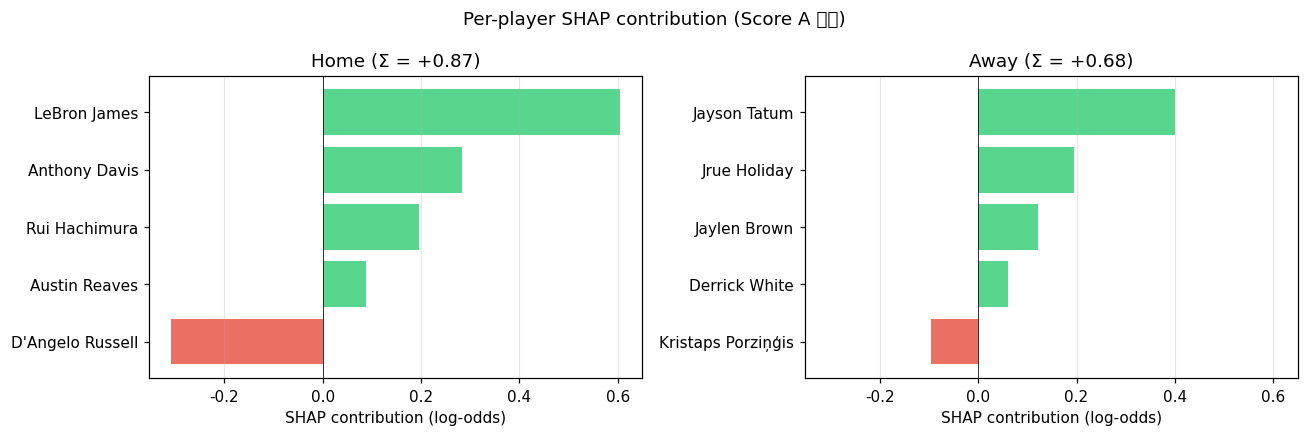

In [4]:
# 視覺化：兩隊 per-player SHAP 對比
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, side_df, title in [
    (axes[0], result['per_player_shap_home'], f'Home (Σ = {result["score_A_home"]:+.2f})'),
    (axes[1], result['per_player_shap_away'], f'Away (Σ = {result["score_A_away"]:+.2f})'),
]:
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in side_df['shap_sum']]
    ax.barh(side_df['player_name'], side_df['shap_sum'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('SHAP contribution (log-odds)')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Per-player SHAP contribution (Score A 分解)')
fig.tight_layout()


## ⚡ 模型 spread 確認 — 極端對比

案例 A 如果接近五五波，不是因為模型壓在 50% 附近，而是因為 LAL 和 BOS 都是強隊。換成 **OKC vs WAS**（2024-25 強隊 vs 弱隊）就會拉開。


In [5]:
# OKC 起手 5 vs 2024-25 WAS 起手 5
okc = ['Shai Gilgeous-Alexander', 'Jalen Williams', 'Chet Holmgren',
       'Luguentz Dort', 'Isaiah Hartenstein']
was = ['Jordan Poole', 'Bilal Coulibaly', 'Alex Sarr',
       'Bub Carrington', 'Kyle Kuzma']

result_extreme = predict_matchup(
    [find_player(n) for n in okc],
    [find_player(n) for n in was],
    snapshot_date='2025-03-01',
)
print(f'OKC vs WAS @ 2025-03-01:')
print(f'  P(OKC wins) = {result_extreme["P_home_win"]:.3f}')
print(f'  ΔA (z): {result_extreme["delta_A"]:+.2f}')
print(f'  ΔB (z): {result_extreme["delta_B"]:+.2f}')
print(f'  Score_C(z): {result_extreme["score_C_z"]:+.2f}')
print(f'  Δpm(z): {result_extreme["delta_pm"]:+.2f}')

# 對照 LAL vs BOS
print()
print(f'LAL vs BOS @ 2025-03-01 (對照):')
print(f'  P(LAL wins) = {result["P_home_win"]:.3f}')
print(f'  ΔA (z): {result["delta_A"]:+.2f}')
print(f'  ΔB (z): {result["delta_B"]:+.2f}')
print(f'  Score_C(z): {result["score_C_z"]:+.2f}')
print(f'  Δpm(z): {result["delta_pm"]:+.2f}')


OKC vs WAS @ 2025-03-01:
  P(OKC wins) = 0.830
  ΔA (z): +0.40
  ΔB (z): +0.26
  Score_C(z): -0.94
  Δpm(z): +2.47

LAL vs BOS @ 2025-03-01 (對照):
  P(LAL wins) = 0.594
  ΔA (z): +0.12
  ΔB (z): +0.14
  Score_C(z): -1.30
  Δpm(z): +0.11


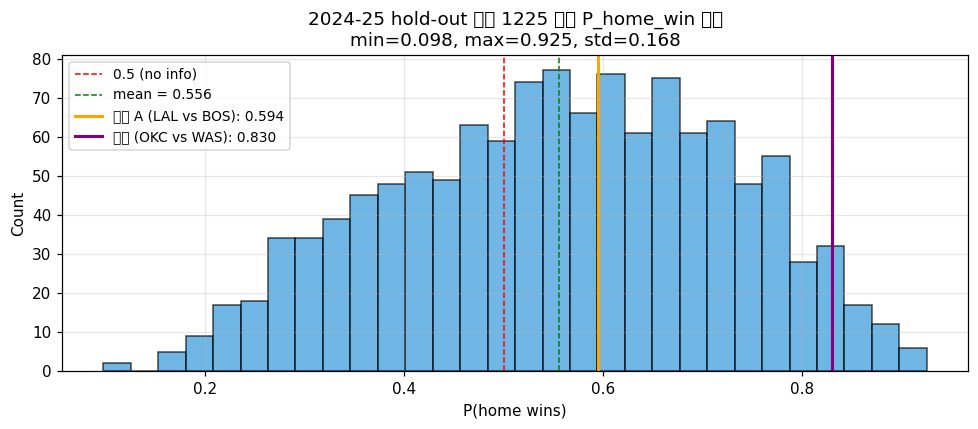

In [6]:
# 整個 2024-25 test set 的 P_home_win 分布 — 證明模型不是壓在 50%
import pandas as pd
test_preds = pd.read_csv('outputs/predictions_test.csv')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_preds['P_home_win'], bins=30, edgecolor='black', alpha=0.7, color='#3498db')
ax.axvline(0.5, color='red', ls='--', lw=1, label='0.5 (no info)')
ax.axvline(test_preds['P_home_win'].mean(), color='green', ls='--', lw=1,
           label=f'mean = {test_preds["P_home_win"].mean():.3f}')

# 標記三個 demo 點
ax.axvline(result['P_home_win'], color='orange', lw=2,
           label=f'案例 A (LAL vs BOS): {result["P_home_win"]:.3f}')
ax.axvline(result_extreme['P_home_win'], color='purple', lw=2,
           label=f'極端 (OKC vs WAS): {result_extreme["P_home_win"]:.3f}')

ax.set_xlabel('P(home wins)')
ax.set_ylabel('Count')
ax.set_title(f'2024-25 hold-out 全部 {len(test_preds)} 場的 P_home_win 分布\n'
             f'min={test_preds["P_home_win"].min():.3f}, max={test_preds["P_home_win"].max():.3f}, '
             f'std={test_preds["P_home_win"].std():.3f}')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()


## 2. 案例 B — 球員交換 What-if

把主隊的 LeBron 換成 Luka Dončić，看勝率怎麼變。

In [7]:
home_swap = home_names.copy()
home_swap[0] = 'Doncic'  # LeBron → Luka

result_swap = predict_matchup(
    [find_player(n) for n in home_swap],
    away_ids,
    snapshot_date='2025-03-01',
)

delta_p = result_swap['P_home_win'] - result['P_home_win']
print(f"原 lineup P(home win) = {result['P_home_win']:.3f}")
print(f"換後 P(home win)      = {result_swap['P_home_win']:.3f}")
print(f"勝率變化              = {delta_p:+.4f}")

# 兩種 lineup 的維度對比
comparison = pd.DataFrame({
    'LeBron版': summary_table(result).iloc[0],
    'Doncic版': summary_table(result_swap).iloc[0],
})
comparison['差異'] = comparison['Doncic版'] - comparison['LeBron版']
comparison.round(3)


原 lineup P(home win) = 0.594
換後 P(home win)      = 0.562
勝率變化              = -0.0323


,LeBron版,Doncic版,差異
P_home_win,0.594,0.562,-0.032
Score_A_home,0.865,0.444,-0.421
Score_A_away,0.683,0.683,0.000
ΔA_z,0.123,-0.170,-0.292
Score_B_home,0.153,0.078,-0.075
Score_B_away,0.092,0.092,0.000
ΔB_z,0.143,-0.074,-0.216
Score_C_z,-1.297,-1.457,-0.160
pm_home,5.380,4.960,-0.420
pm_away,4.920,4.920,0.000


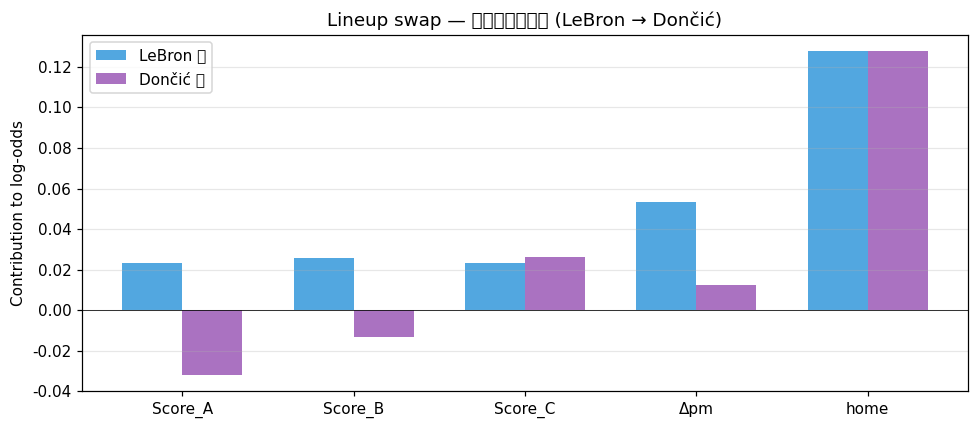

In [8]:
# 視覺化：五個 logit 維度的貢獻差異
fig, ax = plt.subplots(figsize=(9, 4))
comps = ['from_delta_A', 'from_delta_B', 'from_score_C', 'from_delta_pm', 'from_is_home']
labels = ['Score_A', 'Score_B', 'Score_C', 'Δpm', 'home']
x = np.arange(len(comps))
w = 0.35
ax.bar(x - w/2, [result['logit_contributions'].get(c, 0) for c in comps],
       w, label='LeBron 版', color='#3498db', alpha=0.85)
ax.bar(x + w/2, [result_swap['logit_contributions'].get(c, 0) for c in comps],
       w, label='Dončić 版', color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Contribution to log-odds')
ax.set_title('Lineup swap — 各維度貢獻對比 (LeBron → Dončić)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()


## 3. 案例 C — 中性場與對稱強弱比較

`is_home=0` 是把主場係數拿掉；`symmetric=True` 是用 forward/reverse logit 反對稱化，適合回答「兩隊中性場誰比較強」。


In [9]:
result_no_home = predict_matchup(home_ids, away_ids,
                                 snapshot_date='2025-03-01',
                                 is_home=0)
result_symmetric = predict_matchup(home_ids, away_ids,
                                   snapshot_date='2025-03-01',
                                   symmetric=True)
result_swap_symmetric = predict_matchup(away_ids, home_ids,
                                        snapshot_date='2025-03-01',
                                        symmetric=True)

print(f"一般主場預測 P(LAL home win) = {result['P_home_win']:.3f}")
print(f"拿掉主場係數 is_home=0       = {result_no_home['P_home_win']:.3f}")
print(f"對稱強弱比較 symmetric=True = {result_symmetric['P_home_win']:.3f}")
print(f"主場係數影響                 = {result['P_home_win'] - result_no_home['P_home_win']:+.4f}")

print()
print(f"對稱性檢查:")
print(f"  P(LAL stronger than BOS) = {result_symmetric['P_home_win']:.4f}")
print(f"  P(BOS stronger than LAL) = {result_swap_symmetric['P_home_win']:.4f}")
print(f"  相加                     = {result_symmetric['P_home_win'] + result_swap_symmetric['P_home_win']:.4f}  (≈ 1)")


一般主場預測 P(LAL home win) = 0.594
拿掉主場係數 is_home=0       = 0.563
對稱強弱比較 symmetric=True = 0.531
主場係數影響                 = +0.0312

對稱性檢查:
  P(LAL stronger than BOS) = 0.5312
  P(BOS stronger than LAL) = 0.4694
  相加                     = 1.0006  (≈ 1)


## 4. 案例 D — 不限 5 人，輸入 7 名球員

In [10]:
# 提案說「任意 N 名球員」，model 結構天然支援
home_7 = home_names + ['Max Christie', 'Gabe Vincent']
away_7 = away_names + ['Sam Hauser', 'Payton Pritchard']

result_7 = predict_matchup(
    [find_player(n) for n in home_7],
    [find_player(n) for n in away_7],
    snapshot_date='2025-03-01',
)
print(f"5v5 (起手 5 人):  P(home win) = {result['P_home_win']:.3f}")
print(f"7v7 (含板凳):     P(home win) = {result_7['P_home_win']:.3f}")

# 板凳對 Score_A 的拖累 / 加成
print(f"\nHome side Score_A (Σ SHAP):")
print(f"  5 人: {result['score_A_home']:+.3f}")
print(f"  7 人: {result_7['score_A_home']:+.3f}  (差異: {result_7['score_A_home']-result['score_A_home']:+.3f})")

result_7['per_player_shap_home'][['player_name','min_roll10','shap_sum']].round(3)


5v5 (起手 5 人):  P(home win) = 0.594
7v7 (含板凳):     P(home win) = 0.543

Home side Score_A (Σ SHAP):
  5 人: +0.865
  7 人: +1.099  (差異: +0.234)


,player_name,min_roll10,shap_sum
0,LeBron James,34.96,0.605
1,Anthony Davis,35.31,0.283
2,Max Christie,33.04,0.233
3,Rui Hachimura,35.18,0.196
4,Austin Reaves,34.12,0.088
5,Gabe Vincent,20.68,0.000
6,D'Angelo Russell,25.19,-0.307


## 5. 案例 E — 跨時空快照

同一支隊伍、不同時間點：2020-21 LAL vs 2024-25 LAL。

注意：SHAP 是在當下 lineup/context 裡的邊際貢獻，不是純粹的個人 aging 指標。這段 demo 的重點是展示 `snapshot_date` 可以做時間旅行查詢，而不是宣稱 LeBron/AD 的個人能力被完全隔離出來。


In [11]:
# 2020-21 LAL 起手 5 (championship-era core)
lal_2021 = ['LeBron James', 'Anthony Davis', 'Dennis Schroder',
            'Kentavious Caldwell-Pope', 'Marc Gasol']

result_2021 = predict_matchup(
    [find_player(n) for n in lal_2021],
    away_ids,
    snapshot_date='2021-04-01',
)

print(f"2020-21 LAL 快照查詢:")
print(f"  Snapshot:    {result_2021['snapshot_date']}, P80 賽季: {result_2021['season_for_p80']}")
print(f"  P(home win): {result_2021['P_home_win']:.3f}")

print()
print(f"2024-25 LAL 快照查詢 (案例 A):")
print(f"  Snapshot:    {result['snapshot_date']}, P80 賽季: {result['season_for_p80']}")
print(f"  P(home win): {result['P_home_win']:.3f}")

# 同一個 LeBron 在兩個時間點的 SHAP 對照：只能解讀為 lineup/context 內貢獻
lbj_2021 = result_2021['per_player_shap_home'].query("player_name.str.contains('James')")['shap_sum'].iloc[0]
lbj_2025 = result['per_player_shap_home'].query("player_name.str.contains('James')")['shap_sum'].iloc[0]
ad_2021  = result_2021['per_player_shap_home'].query("player_name=='Anthony Davis'")['shap_sum'].iloc[0]
ad_2025  = result['per_player_shap_home'].query("player_name=='Anthony Davis'")['shap_sum'].iloc[0]

print()
print(f"SHAP 對照 (context-dependent log-odds):")
print(f"  LeBron 2020-21: {lbj_2021:+.3f}")
print(f"  LeBron 2024-25: {lbj_2025:+.3f}")
print(f"  AD     2020-21: {ad_2021:+.3f}")
print(f"  AD     2024-25: {ad_2025:+.3f}")


2020-21 LAL 快照查詢:
  Snapshot:    2021-04-01, P80 賽季: 2020-21
  P(home win): 0.515

2024-25 LAL 快照查詢 (案例 A):
  Snapshot:    2025-03-01, P80 賽季: 2024-25
  P(home win): 0.594

SHAP 對照 (context-dependent log-odds):
  LeBron 2020-21: +0.404
  LeBron 2024-25: +0.605
  AD     2020-21: -0.048
  AD     2024-25: +0.283


## 6. 設計重點

- **任意 N 名球員**：Score_A 是 Σ SHAP，Score_B 是 max/sum 聚合，Score_C 是雙方技能交互，Δpm 是 mean → 全部天然支援任意陣容。
- **稀疏化**：Output B 改用 L1，這次 54 個 features 留下 13 個，減少罕見交乘雜訊。
- **對稱性**：一般主場預測保留 home/intercept；中性強弱比較用 `symmetric=True`，見案例 C。
- **時間旅行**：`snapshot_date` 取該日前最近一筆 rolling stats；跨年 SHAP 只能解讀為當下 lineup/context 內貢獻。
- **可解釋**：`per_player_shap_*` 拆解到球員、`logit_contributions` 拆解到 Score_A / Score_B / Score_C / Δpm / home。
- **校準診斷**：`outputs/calibration_buckets.csv` 和 `outputs/calibration_bucket_045_050.csv` 可用來展示模型盲點。
